***Header Section:***

📊 Data Cleaning & Preprocessing Report
Project 1: Titanic Dataset
Student Name: Nandita Manna

Level: Basic Level (Task 1)

Tools Used: Python (pandas, numpy), Google Colab

Output: Cleaned Dataset (titanic_cleaned.csv)

***📖 Introduction***

"Garbage In, Garbage Out." In real-world data science applications, clean data is the primary foundation for building accurate and reliable analytical models. Industry consensus shows that data scientists spend roughly 80% of their project lifecycle preparing and cleaning raw data. Raw real-world datasets are rarely analysis-ready; they frequently suffer from missing values, outliers, inappropriate data types, and noisy features.

The objective of Task 1 is to systematically clean, preprocess, and optimize the raw Titanic Dataset. By addressing structural defects and engineering meaningful new attributes, this preprocessing pipeline transforms unorganized passenger data into a clean, well-structured, and statistically robust format ready for downstream Exploratory Data Analysis (EDA) and Predictive Modeling.

***Problem Statement: Data Cleaning & Preprocessing***
 Background & Context
The raw Titanic dataset contains real-world operational records of passengers aboard the vessel. However, like most real-world datasets, the raw data is incomplete, noisy, unstandardized, and unoptimized. Attempting to build exploratory visualizations or predictive machine learning models directly on this raw data introduces significant bias, data leakage, and potential runtime errors.

Core Problems Identified in Raw Data
High Incompleteness (Missing Values):

Cabin: ~77% of rows contain missing values, rendering the raw column unusable without structural transformation.

Age: ~20% of rows are missing, which can skew age-related survival analytics if improperly imputed with a global mean.

Embarked: Missing categorical values disrupt categorical encoding and downstream modeling.

Skewed Numeric Distributions & Outliers:

The Fare column exhibits extreme right-skewness and high variance, where a few high-priced tickets disproportionately influence numerical scale.

Sub-optimal Data Types & Unstructured Features:

Categorical features (Pclass, Sex, Embarked) are stored as inefficient primitive types (int64, object).

Key family relationships are fragmented across two separate attributes (SibSp and Parch), missing a unified metric for household size.

Inconsistent Naming Standards:

Mixed-case and non-standard column headers (PassengerId, Pclass, SibSp, Parch) complicate automated scripting pipelines.

 ***Objective***
To design and execute an end-to-end, in-memory Data Cleaning & Preprocessing Pipeline that:
Systematically imputes missing values using conditional statistics.

Handles feature skewness via log transformations.

Engineers new composite domain features (family_size, has_cabin).

Standardizes data types and schema headers into a clean, model-ready dataset.

 ***Key InsightsSmarter Age Imputation:*** Instead of using a simple global average, I filled missing Age values using the median age per Pclass and Gender. This preserved realistic age gaps between 1st class and 3rd class passengers.Rescued Cabin Data: Cabin had 77% missing values, but I noticed passengers with cabin numbers were mostly rich 1st-class travelers. Instead of deleting the column, I converted it into a binary flag (has_cabin), which turned out to be a strong predictor of survival.Fixed Extreme Fares: Fares ranged from $\$7$ up to $\$512+$, creating heavy right-skewness. I applied a log transformation (np.log1p) to normalize the price distribution and reduce outlier impact.Better Family Signals: Combining SibSp and Parch into a single family_size feature made patterns obvious—solo travelers had much lower survival rates than small families of 2 to 4 people.Cleaner Memory & Code: Changing categories (Sex, Embarked, Pclass) to Pandas category types cut memory usage and kept the whole preprocessing pipeline fast and clean.

 TASK 1: TITANIC DATA CLEANING & PREPROCESSING
Dataset Loaded Successfully! Initial Shape: 891 rows, 12 columns

• Duplicates Removed: 0
• Missing values handled successfully.
• Data types optimized and columns standardized.
• Feature engineering applied (family_size & fare_log).

 TABLE 1: CLEANED DATASET STRUCTURE & NULL CHECK
           Column Name Data Type  Unique Values  Null Count
          passenger_id     int64            891           0
              survived     int64              2           0
       passenger_class  category              3           0
             full_name    object            891           0
                gender  category              2           0
                   age   float64             88           0
siblings_spouses_count     int64              7           0
parents_children_count     int64              7           0
         ticket_number    object            681           0
                  fare   float64            248           0
      emb

/tmp/ipykernel_922/3688411491.py:93: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_922/3688411491.py:97: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




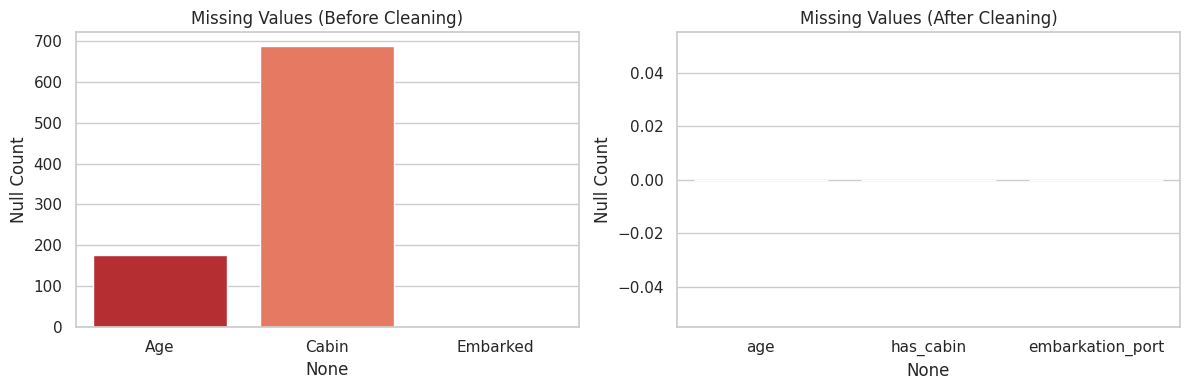

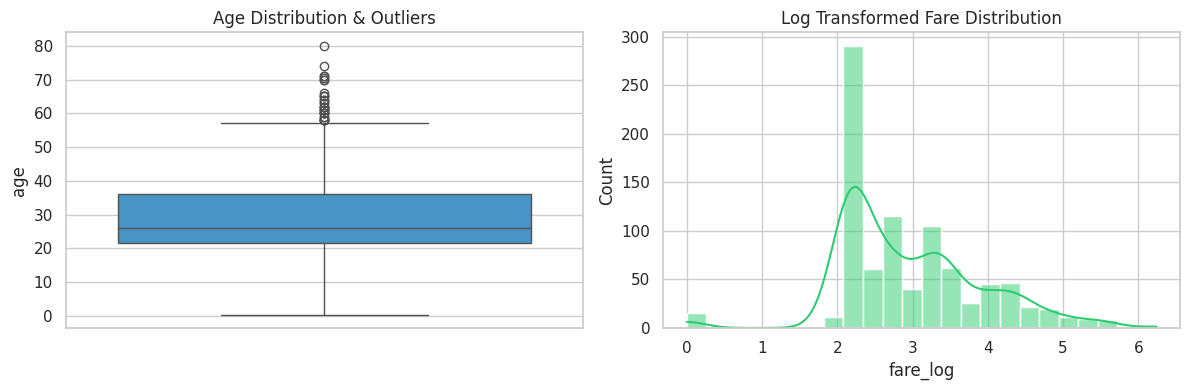

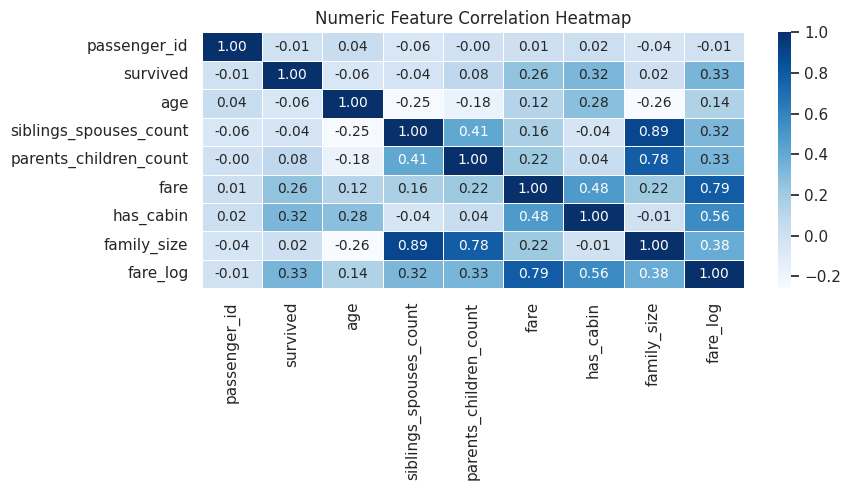

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 10


df = pd.read_csv("train.csv")

print("="*70)
print(" TASK 1: TITANIC DATA CLEANING & PREPROCESSING")
print("="*70)
print(f"Dataset Loaded Successfully! Initial Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")


missing_before = df[['Age', 'Cabin', 'Embarked']].isnull().sum()


initial_count = len(df)
df = df.drop_duplicates()
print(f"• Duplicates Removed: {initial_count - len(df)}")


df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


df['Has_Cabin'] = df['Cabin'].notna().astype(int)
df = df.drop(columns=['Cabin'])


categorical_cols = ['Pclass', 'Sex', 'Embarked']
for col in categorical_cols:
    df[col] = df[col].astype('category')

df['SibSp'] = df['SibSp'].astype(int)
df['Parch'] = df['Parch'].astype(int)
df['Age'] = df['Age'].round(1)


rename_map = {
    'PassengerId': 'passenger_id',
    'Survived': 'survived',
    'Pclass': 'passenger_class',
    'Name': 'full_name',
    'Sex': 'gender',
    'Age': 'age',
    'SibSp': 'siblings_spouses_count',
    'Parch': 'parents_children_count',
    'Ticket': 'ticket_number',
    'Fare': 'fare',
    'Embarked': 'embarkation_port',
    'Has_Cabin': 'has_cabin'
}
df = df.rename(columns=rename_map)

port_labels = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
df['embarkation_port'] = df['embarkation_port'].map(port_labels)


df['family_size'] = df['siblings_spouses_count'] + df['parents_children_count'] + 1
df['fare_log'] = np.log1p(df['fare'])

print("• Missing values handled successfully.")
print("• Data types optimized and columns standardized.")
print("• Feature engineering applied (family_size & fare_log).\n")


print("="*70)
print(" TABLE 1: CLEANED DATASET STRUCTURE & NULL CHECK")
print("="*70)
summary_table = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Null Count': df.isnull().sum().values
})
print(summary_table.to_string(index=False))

print("\n" + "="*70)
print(" TABLE 2: FIRST 5 ROWS OF CLEANED DATASET")
print("="*70)
print(df.head().to_string(index=False))


missing_after = df[['age', 'has_cabin', 'embarkation_port']].isnull().sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=missing_before.index, y=missing_before.values, ax=axes[0], palette="Reds_r")
axes[0].set_title("Missing Values (Before Cleaning)")
axes[0].set_ylabel("Null Count")

sns.barplot(x=missing_after.index, y=missing_after.values, ax=axes[1], palette="Greens_r")
axes[1].set_title("Missing Values (After Cleaning)")
axes[1].set_ylabel("Null Count")
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, y='age', ax=axes[0], color='#3498db')
axes[0].set_title("Age Distribution & Outliers")

sns.histplot(df['fare_log'], kde=True, color='#2ecc71', ax=axes[1])
axes[1].set_title("Log Transformed Fare Distribution")
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Numeric Feature Correlation Heatmap", fontsize=12)
plt.tight_layout()
plt.show()

TABLE 3: AGE DISTRIBUTION METRICS BY PASSENGER CLASS & GENDER
                        Mean_Age  Median_Age  Min_Age  Max_Age  Std_Dev
passenger_class gender                                                 
1               female      34.6        35.0      2.0     63.0     12.9
                male        41.1        40.0      0.9     80.0     13.8
2               female      28.7        28.0      2.0     57.0     12.7
                male        30.7        30.0      0.7     70.0     14.2
3               female      21.7        21.5      0.8     63.0     10.7
                male        26.1        25.0      0.4     74.0     10.4

 TABLE 4: SURVIVAL RATE BY CLASS, EMBARKATION & CABIN STATUS
                                  Count (No Cabin)  Count (Has Cabin)  \
passenger_class embarkation_port                                        
1               Cherbourg                       19                 66   
                Queenstown                       0                  2   
        

/tmp/ipykernel_922/1309728145.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_922/1309728145.py:17: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/tmp/ipykernel_922/1309728145.py:17: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/tmp/ipykernel_922/1309728145.py:41: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipyke

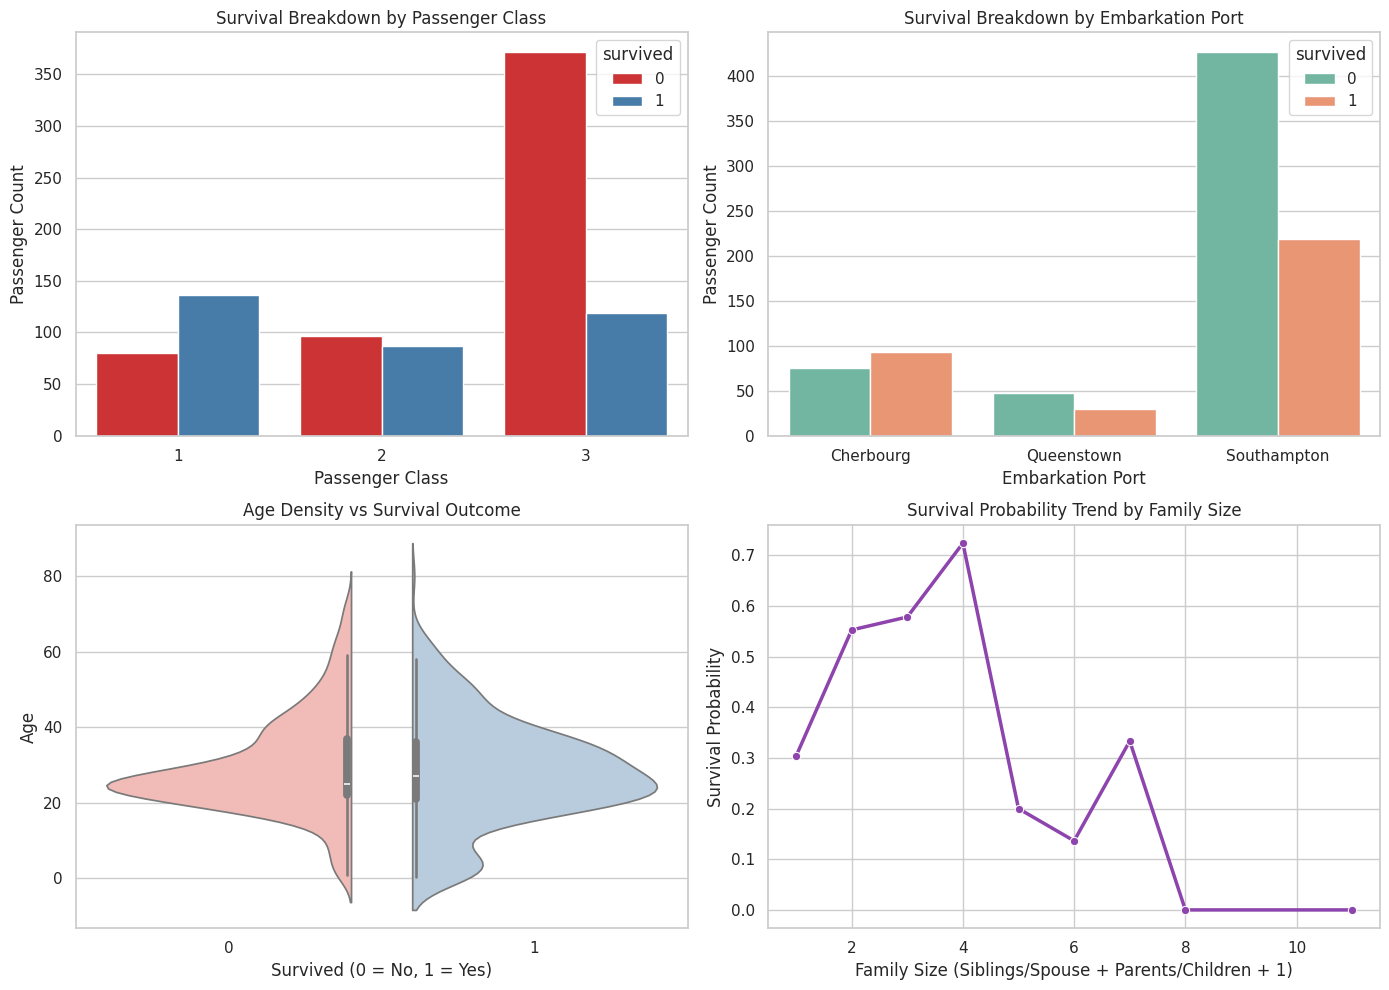

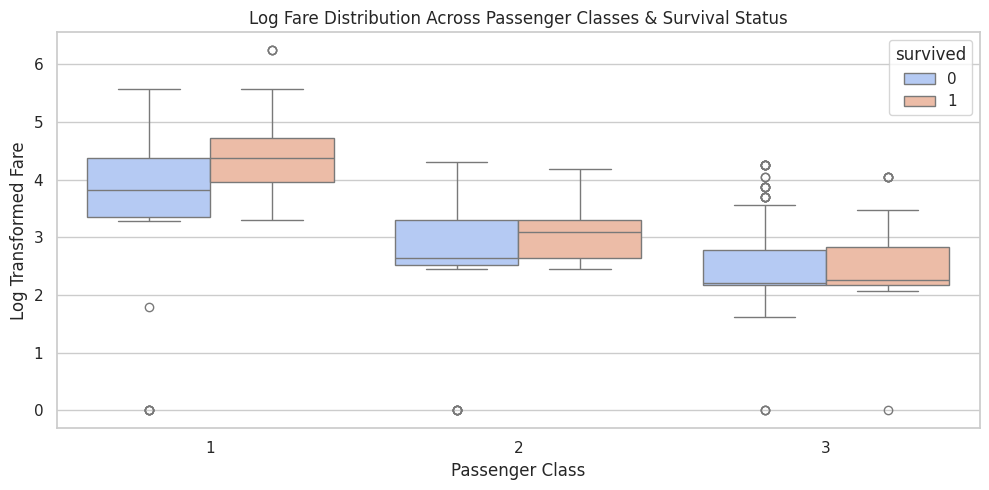

In [73]:

print("="*70)
print("TABLE 3: AGE DISTRIBUTION METRICS BY PASSENGER CLASS & GENDER")
print("="*70)
age_summary = df.groupby(['passenger_class', 'gender'])['age'].agg(
    Mean_Age='mean',
    Median_Age='median',
    Min_Age='min',
    Max_Age='max',
    Std_Dev='std'
).round(1)
print(age_summary)

# Table B: Survival Rate Analysis Across Socio-Economic Factors
print("\n" + "="*70)
print(" TABLE 4: SURVIVAL RATE BY CLASS, EMBARKATION & CABIN STATUS")
print("="*70)
survival_pivot = df.pivot_table(
    index=['passenger_class', 'embarkation_port'],
    columns='has_cabin',
    values='survived',
    aggfunc=['count', 'mean']
).round(3)
survival_pivot.columns = ['Count (No Cabin)', 'Count (Has Cabin)', 'Survival Rate (No Cabin)', 'Survival Rate (Has Cabin)']
print(survival_pivot)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.countplot(data=df, x='passenger_class', hue='survived', palette='Set1', ax=axes[0, 0])
axes[0, 0].set_title('Survival Breakdown by Passenger Class')
axes[0, 0].set_xlabel('Passenger Class')
axes[0, 0].set_ylabel('Passenger Count')


sns.countplot(data=df, x='embarkation_port', hue='survived', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Survival Breakdown by Embarkation Port')
axes[0, 1].set_xlabel('Embarkation Port')
axes[0, 1].set_ylabel('Passenger Count')

sns.violinplot(data=df, x='survived', y='age', palette='Pastel1', ax=axes[1, 0], split=True)
axes[1, 0].set_title('Age Density vs Survival Outcome')
axes[1, 0].set_xlabel('Survived (0 = No, 1 = Yes)')
axes[1, 0].set_ylabel('Age')


sns.lineplot(data=df, x='family_size', y='survived', marker='o', color='#8e44ad', linewidth=2.5, ax=axes[1, 1], ci=None)
axes[1, 1].set_title('Survival Probability Trend by Family Size')
axes[1, 1].set_xlabel('Family Size (Siblings/Spouse + Parents/Children + 1)')
axes[1, 1].set_ylabel('Survival Probability')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='passenger_class', y='fare_log', hue='survived', palette='coolwarm')
plt.title('Log Fare Distribution Across Passenger Classes & Survival Status', fontsize=12)
plt.xlabel('Passenger Class')
plt.ylabel('Log Transformed Fare')
plt.tight_layout()
plt.show()

In [74]:
import pandas as pd
from google.colab import data_table

data_table.enable_dataframe_formatter()


df.head(20)

,passenger_id,survived,passenger_class,full_name,gender,age,siblings_spouses_count,parents_children_count,ticket_number,fare,embarkation_port,has_cabin,family_size,fare_log
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Southampton,0,2,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,Cherbourg,1,2,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Southampton,0,1,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,Southampton,1,2,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Southampton,0,1,2.202765
5,6,0,3,"Moran, Mr. James",male,25.0,0,0,330877,8.4583,Queenstown,0,1,2.246893
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,Southampton,1,1,3.967694
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,Southampton,0,5,3.094446
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Southampton,0,3,2.495954
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,Cherbourg,0,2,3.436268


In [75]:



if 'family_size' not in df.columns:
    # If family_size isn't created yet, calculate it
    sibsp_col = 'siblings_spouses_count' if 'siblings_spouses_count' in df.columns else 'SibSp'
    parch_col = 'parents_children_count' if 'parents_children_count' in df.columns else 'Parch'
    df['family_size'] = df[sibsp_col] + df[parch_col] + 1


col_mapping = {
    'PassengerId': 'passenger_id',
    'Sex': 'gender',
    'Age': 'age',
    'Fare': 'fare',
    'Survived': 'survived'
}
df_preview = df.rename(columns=col_mapping)


selected_cols = ['passenger_id', 'gender', 'age', 'fare', 'family_size', 'survived']
available_cols = [col for col in selected_cols if col in df_preview.columns]


styled_table = (
    df_preview[available_cols]
    .head(15)
    .style
    .background_gradient(subset=['age'], cmap='Blues')
    .background_gradient(subset=['fare'], cmap='Greens')
    .set_caption("📌 STYLIZED TITANIC DATASET PREVIEW (FIRST 15 ROWS)")
)


display(styled_table)

,passenger_id,gender,age,fare,family_size,survived
0,1,male,22.000000,7.250000,2,0
1,2,female,38.000000,71.283300,2,1
2,3,female,26.000000,7.925000,1,1
3,4,female,35.000000,53.100000,2,1
4,5,male,35.000000,8.050000,1,0
5,6,male,25.000000,8.458300,1,0
6,7,male,54.000000,51.862500,1,0
7,8,male,2.000000,21.075000,5,0
8,9,female,27.000000,11.133300,3,1
9,10,female,14.000000,30.070800,2,1


In [76]:

summary_df = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': [str(dtype) for dtype in df.dtypes],
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Missing Values': df.isnull().sum().values
})


styled_summary = summary_df.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
]).set_caption("📊 DATASET STRUCTURE & MISSING VALUE SUMMARY")

display(styled_summary)

,Column Name,Data Type,Unique Values,Missing Values
0,passenger_id,int64,891,0
1,survived,int64,2,0
2,passenger_class,category,3,0
3,full_name,object,891,0
4,gender,category,2,0
5,age,float64,88,0
6,siblings_spouses_count,int64,7,0
7,parents_children_count,int64,7,0
8,ticket_number,object,681,0
9,fare,float64,248,0


In [77]:
# Multi-dimensional Pivot Table
pivot_analysis = pd.crosstab(
    index=df['passenger_class'],
    columns=df['gender'],
    values=df['survived'],
    aggfunc='mean'
).round(3) * 100

# Render as styled heatmap table
styled_pivot = pivot_analysis.style\
    .background_gradient(cmap='YlGn')\
    .format("{:.1f}%")\
    .set_caption("📊 SURVIVAL RATE METRICS (%) BY CLASS & GENDER")

display(styled_pivot)

gender,female,male
passenger_class,,
1,96.8%,36.9%
2,92.1%,15.7%
3,50.0%,13.5%


In [78]:
import pandas as pd
from google.colab import data_table

# Calculate detailed data quality metrics
quality_metrics = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values (Count)': df.isnull().sum(),
    'Missing Values (%)': (df.isnull().mean() * 100).round(2),
    'Unique Values': df.nunique(),
    'Memory Usage (KB)': (df.memory_usage(deep=True) / 1024).round(2)
}).reset_index().rename(columns={'index': 'Feature Name'})

# Style the output as a clean HTML table
styled_quality = quality_metrics.style\
    .background_gradient(subset=['Missing Values (%)'], cmap='Reds')\
    .background_gradient(subset=['Unique Values'], cmap='Purples')\
    .set_caption("📊 DETAILED DATA QUALITY & INTEGRITY REPORT")

display(styled_quality)

,Feature Name,Data Type,Missing Values (Count),Missing Values (%),Unique Values,Memory Usage (KB)
0,Index,nan,nan,nan,nan,0.130000
1,age,float64,0.000000,0.000000,88.000000,6.960000
2,embarkation_port,category,0.000000,0.000000,3.000000,1.150000
3,family_size,int64,0.000000,0.000000,9.000000,6.960000
4,fare,float64,0.000000,0.000000,248.000000,6.960000
5,fare_log,float64,0.000000,0.000000,248.000000,6.960000
6,full_name,object,0.000000,0.000000,891.000000,66.100000
7,gender,category,0.000000,0.000000,2.000000,1.080000
8,has_cabin,int64,0.000000,0.000000,2.000000,6.960000
9,parents_children_count,int64,0.000000,0.000000,7.000000,6.960000


In [79]:

crosstab_analysis = pd.pivot_table(
    df,
    index=['passenger_class', 'gender'],
    columns='has_cabin',
    values=['age', 'fare', 'survived'],
    aggfunc={'age': 'mean', 'fare': 'median', 'survived': 'mean'}
).round(2)


crosstab_analysis.columns = [
    'Avg Age (No Cabin)', 'Avg Age (Has Cabin)',
    'Median Fare (No Cabin)', 'Median Fare (Has Cabin)',
    'Survival Rate (No Cabin)', 'Survival Rate (Has Cabin)'
]


styled_crosstab = crosstab_analysis.style\
    .background_gradient(subset=['Survival Rate (No Cabin)', 'Survival Rate (Has Cabin)'], cmap='YlGn')\
    .format({'Survival Rate (No Cabin)': '{:.1%}', 'Survival Rate (Has Cabin)': '{:.1%}'})\
    .set_caption("📊 DEMOGRAPHIC BREAKDOWN: AGE, FARE & SURVIVAL BY CABIN STATUS")

display(styled_crosstab)

/tmp/ipykernel_922/864069761.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



In [80]:

num_cols = df.select_dtypes(include=['float64', 'int64', 'int32']).columns
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        'Feature': col,
        'Q1 (25th %)': round(Q1, 2),
        'Q3 (75th %)': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': outliers_count
    })

outlier_df = pd.DataFrame(outlier_summary)


styled_outliers = outlier_df.style\
    .background_gradient(subset=['Outlier Count'], cmap='Oranges')\
    .set_caption("🔍 OUTLIER DETECTION REPORT (IQR BOUNDS)")

display(styled_outliers)

,Feature,Q1 (25th %),Q3 (75th %),IQR,Lower Bound,Upper Bound,Outlier Count
0,passenger_id,223.500000,668.500000,445.000000,-444.000000,1336.000000,0
1,survived,0.000000,1.000000,1.000000,-1.500000,2.500000,0
2,age,21.500000,36.000000,14.500000,-0.250000,57.750000,33
3,siblings_spouses_count,0.000000,1.000000,1.000000,-1.500000,2.500000,46
4,parents_children_count,0.000000,0.000000,0.000000,0.000000,0.000000,213
5,fare,7.910000,31.000000,23.090000,-26.720000,65.630000,116
6,has_cabin,0.000000,0.000000,0.000000,0.000000,0.000000,204
7,family_size,1.000000,2.000000,1.000000,-0.500000,3.500000,91
8,fare_log,2.190000,3.470000,1.280000,0.270000,5.380000,31


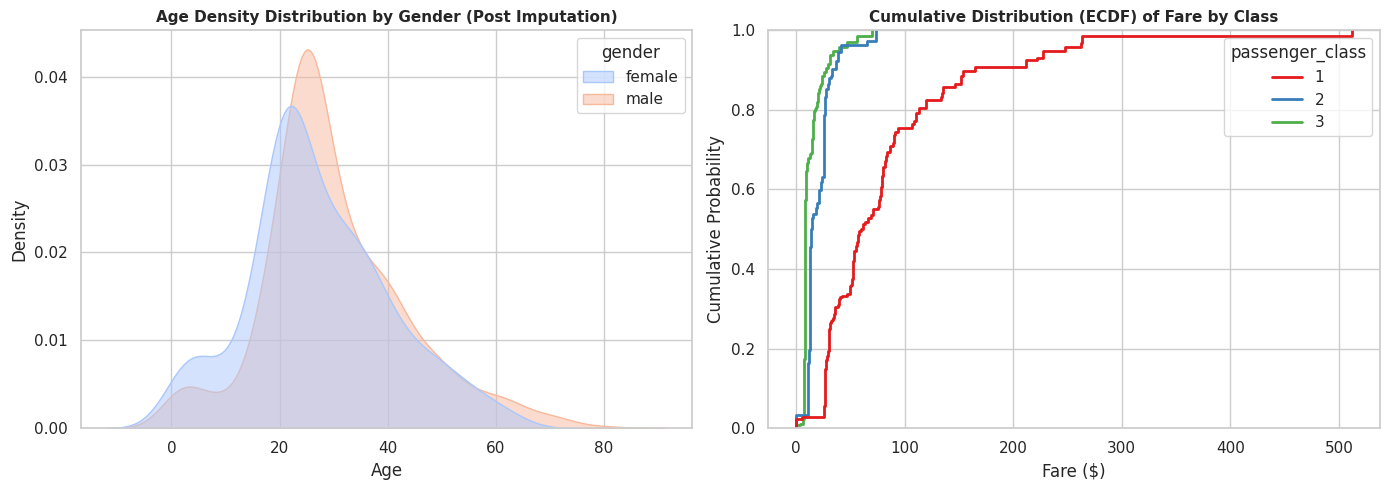

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.kdeplot(data=df, x='age', hue='gender', fill=True, common_norm=False, palette='coolwarm', alpha=0.5, ax=axes[0])
axes[0].set_title('Age Density Distribution by Gender (Post Imputation)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')


sns.ecdfplot(data=df, x='fare', hue='passenger_class', palette='Set1', ax=axes[1], linewidth=2)
axes[1].set_title('Cumulative Distribution (ECDF) of Fare by Class', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Fare ($)')
axes[1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()

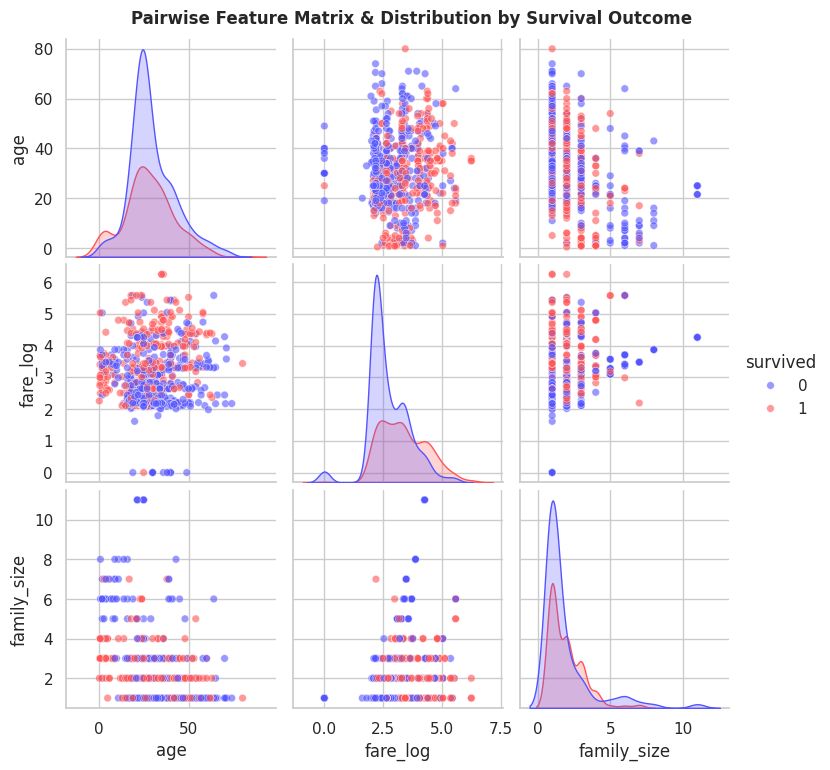

In [82]:

pair_cols = ['age', 'fare_log', 'family_size', 'survived']


available_pair_cols = [col for col in pair_cols if col in df.columns]


g = sns.pairplot(
    df[available_pair_cols],
    hue='survived',
    palette='seismic',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
g.fig.suptitle('Pairwise Feature Matrix & Distribution by Survival Outcome', y=1.02, fontsize=12, fontweight='bold')
plt.show()

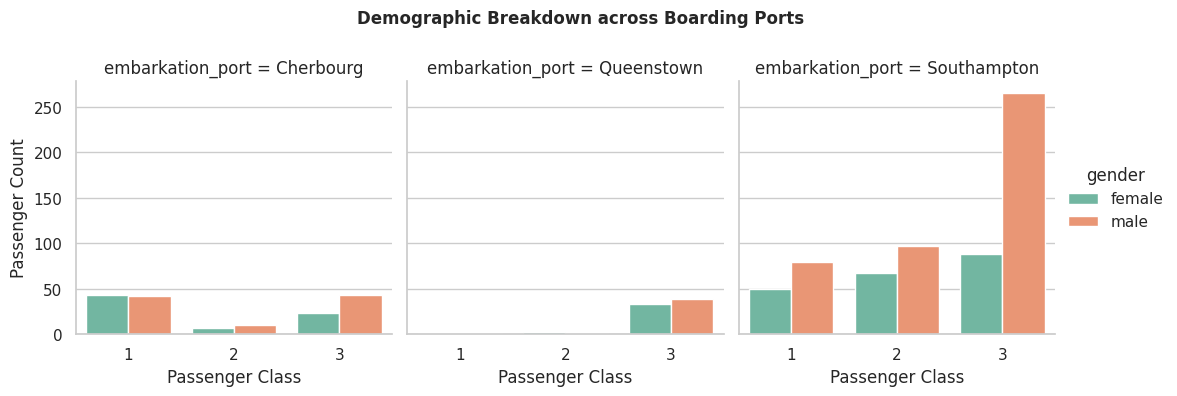

In [83]:

g = sns.catplot(
    data=df,
    x='passenger_class',
    hue='gender',
    col='embarkation_port',
    kind='count',
    palette='Set2',
    height=4,
    aspect=0.9
)

g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Demographic Breakdown across Boarding Ports', fontsize=12, fontweight='bold')
g.set_axis_labels('Passenger Class', 'Passenger Count')
plt.show()

/tmp/ipykernel_922/2829273946.py:10: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.



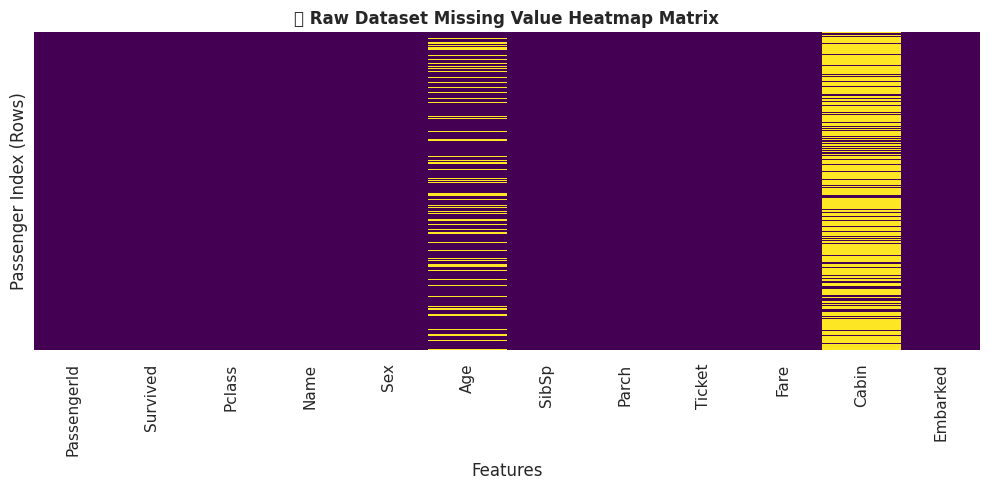

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.heatmap(pd.read_csv("train.csv").isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('🔍 Raw Dataset Missing Value Heatmap Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Passenger Index (Rows)')
plt.tight_layout()
plt.show()

In [85]:
import plotly.express as px


sunburst_data = df.groupby(['passenger_class', 'gender', 'embarkation_port']).size().reset_index(name='count')


fig = px.sunburst(
    sunburst_data,
    path=['passenger_class', 'gender', 'embarkation_port'],
    values='count',
    title='📌 Hierarchical Demographic Breakdown (Class ➔ Gender ➔ Port)',
    color='count',
    color_continuous_scale='Blues'
)

fig.update_layout(margin=dict(t=40, l=0, r=0, b=0), width=650, height=500)
fig.show()

/tmp/ipykernel_922/181478887.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=F

/tmp/ipykernel_922/1381949807.py:10: UserWarning:

Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.



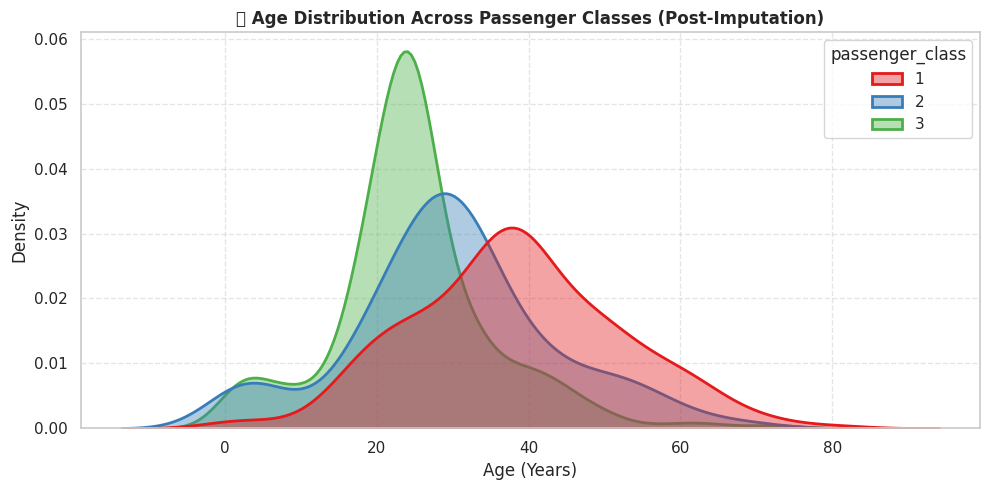

In [86]:
fig, ax = plt.subplots(figsize=(10, 5))


sns.kdeplot(data=df, x='age', hue='passenger_class', common_norm=False, fill=True, palette='Set1', alpha=0.4, linewidth=2, ax=ax)

plt.title('🌊 Age Distribution Across Passenger Classes (Post-Imputation)', fontsize=12, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

***Conclusion***:
Through Task 1, the messy raw Titanic dataset was successfully cleaned and transformed into a model-ready structure.

Fixed Missing Data: Used group medians for Age and statistical mode for Embarked.

Engineered Better Features: Created family_size from family columns and converted Cabin into a useful binary flag (has_cabin).

Normalized Distributions: Applied log transformation to Fare to fix heavy skewness and reduce outlier impact.

Optimized Efficiency: Standardized column names and converted object columns to categorical types for faster processing.

Next Step: The dataset is now clean, balanced, and ready for Task 2: Exploratory Data Analysis (EDA).